In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
BASE_DIR = "/content/drive/MyDrive/Senior_Project/00_Data/cleaned/Final_Short_Form"

PATHS = {
    "liar": {"train": f"{BASE_DIR}/LIAR/train_liar.csv", "test": f"{BASE_DIR}/LIAR/test_liar.csv"},
    "covid": {"train": f"{BASE_DIR}/COVID/train_covid.csv", "test": f"{BASE_DIR}/COVID/test_covid.csv"},
    "sensational": {"train": f"{BASE_DIR}/Sensational/train_sensational.csv", "test": f"{BASE_DIR}/Sensational/test_sensational.csv"},
    "baseline": {"train": f"{BASE_DIR}/LIAR+COVID/train_liar_covid.csv", "test": f"{BASE_DIR}/LIAR+COVID/test_liar_covid.csv"},
    "combined": {"train": f"{BASE_DIR}/Combined/train_combined.csv", "test": f"{BASE_DIR}/Combined/test_combined.csv"},
}

OUT_DIR = "/content/drive/MyDrive/Senior_Project/03_Results/Sentiment"
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
vader_cols = ["vader_neg", "vader_neu", "vader_pos", "vader_compound"]

rhetoric_cols = [
    "word_count",
    "char_count",
    "exclamation_count",
    "question_count",
    "all_caps_count",
    "certainty_count",
    "urgency_count",
    "attack_count",
    "second_person_count"
]

feature_cols = vader_cols + rhetoric_cols

In [ ]:
def load_split(train_path, test_path):
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    for df in [train_df, test_df]:
        df["is_fake"] = df["is_fake"].astype(int)

    missing_train = [c for c in feature_cols if c not in train_df.columns]
    missing_test = [c for c in feature_cols if c not in test_df.columns]

    if missing_train:
        raise ValueError(f"Missing train features: {missing_train}")
    if missing_test:
        raise ValueError(f"Missing test features: {missing_test}")

    train_df[feature_cols] = train_df[feature_cols].fillna(0)
    test_df[feature_cols] = test_df[feature_cols].fillna(0)

    return train_df, test_df


def evaluate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }

In [ ]:
models = {
    "SentRhet_LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ]),
    "SentRhet_RF": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    )
}

In [ ]:
# for saving model
trained_sent_rhet_models = {}

In [ ]:
from sklearn.base import clone

results = []

train_setups = ["baseline", "combined"]
test_sets = ["liar", "covid", "baseline", "sensational", "combined"]

for train_name in train_setups:
    train_df = pd.read_csv(PATHS[train_name]["train"])
    X_train = train_df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
    y_train = train_df["is_fake"].astype(int)

    for model_name, base_model in models.items():
        print(f"\nTraining {model_name} on {train_name}")
        model = clone(base_model)
        model.fit(X_train, y_train)
        # Save trained model in memory
        trained_sent_rhet_models[f"{train_name}_{model_name}"] = model

        for test_name in test_sets:
            print(f"Testing on {test_name}")

            test_df = pd.read_csv(PATHS[test_name]["test"])
            X_test = test_df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
            y_test = test_df["is_fake"].astype(int)

            y_pred = model.predict(X_test)
            metrics = evaluate(y_test, y_pred)

            results.append({
                "train_dataset": train_name,
                "test_dataset": test_name,
                "model": model_name,
                **metrics
            })

results_df = pd.DataFrame(results).sort_values("f1", ascending=False)
results_df


Training SentRhet_LogReg on baseline
Testing on liar
Testing on covid
Testing on baseline
Testing on sensational
Testing on combined

Training SentRhet_RF on baseline
Testing on liar
Testing on covid
Testing on baseline
Testing on sensational
Testing on combined

Training SentRhet_LogReg on combined
Testing on liar
Testing on covid
Testing on baseline
Testing on sensational
Testing on combined

Training SentRhet_RF on combined
Testing on liar
Testing on covid
Testing on baseline
Testing on sensational
Testing on combined


,train_dataset,test_dataset,model,accuracy,precision,recall,f1,tn,fp,fn,tp
6,baseline,covid,SentRhet_RF,0.927604,0.934080,0.897252,0.915296,1030,53,86,751
17,combined,baseline,SentRhet_RF,0.848002,0.793051,0.878325,0.833512,1907,405,215,1552
9,baseline,combined,SentRhet_RF,0.824387,0.769709,0.853284,0.809344,1952,482,277,1611
5,baseline,liar,SentRhet_RF,0.770833,0.687662,0.856989,0.763045,868,362,133,797
1,baseline,covid,SentRhet_LogReg,0.746875,0.736205,0.653524,0.692405,887,196,290,547
11,combined,covid,SentRhet_LogReg,0.746354,0.751437,0.624851,0.682322,910,173,314,523
16,combined,covid,SentRhet_RF,0.732292,0.742857,0.590203,0.657790,912,171,343,494
13,combined,sensational,SentRhet_LogReg,0.516529,0.509091,0.925620,0.656891,13,108,9,112
3,baseline,sensational,SentRhet_LogReg,0.491736,0.495652,0.942149,0.649573,5,116,7,114
4,baseline,combined,SentRhet_LogReg,0.601805,0.534123,0.692267,0.602999,1294,1140,581,1307


In [ ]:
OUT_PATH = f"{OUT_DIR}/sentiment_rhetoric_results.csv"
results_df.to_csv(OUT_PATH, index=False)

print("Saved:", OUT_PATH)
results_df

Saved: /content/drive/MyDrive/Senior_Project/03_Results/Sentiment/sentiment_rhetoric_results.csv


,train_dataset,test_dataset,model,accuracy,precision,recall,f1,tn,fp,fn,tp
6,baseline,covid,SentRhet_RF,0.927604,0.934080,0.897252,0.915296,1030,53,86,751
17,combined,baseline,SentRhet_RF,0.848002,0.793051,0.878325,0.833512,1907,405,215,1552
9,baseline,combined,SentRhet_RF,0.824387,0.769709,0.853284,0.809344,1952,482,277,1611
5,baseline,liar,SentRhet_RF,0.770833,0.687662,0.856989,0.763045,868,362,133,797
1,baseline,covid,SentRhet_LogReg,0.746875,0.736205,0.653524,0.692405,887,196,290,547
11,combined,covid,SentRhet_LogReg,0.746354,0.751437,0.624851,0.682322,910,173,314,523
16,combined,covid,SentRhet_RF,0.732292,0.742857,0.590203,0.657790,912,171,343,494
13,combined,sensational,SentRhet_LogReg,0.516529,0.509091,0.925620,0.656891,13,108,9,112
3,baseline,sensational,SentRhet_LogReg,0.491736,0.495652,0.942149,0.649573,5,116,7,114
4,baseline,combined,SentRhet_LogReg,0.601805,0.534123,0.692267,0.602999,1294,1140,581,1307


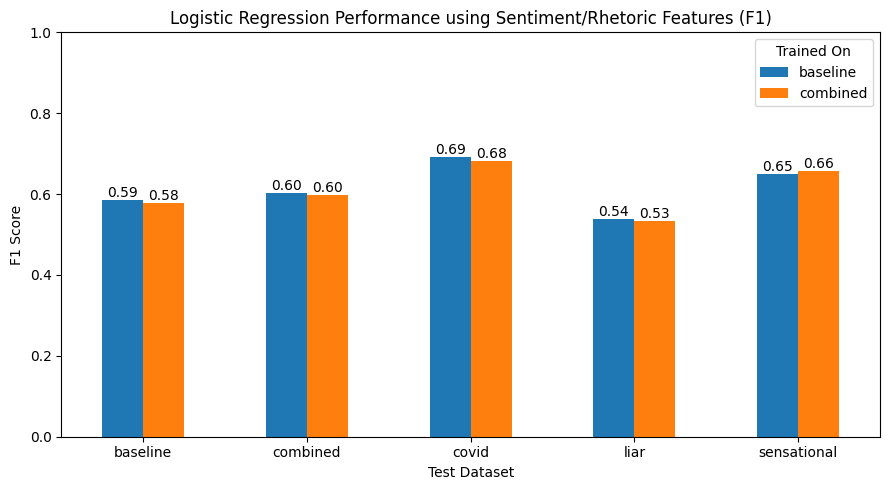

In [ ]:
# Visual: Log Reg F1 comparison

plot_df = results_df[results_df["model"] == "SentRhet_LogReg"]

pivot_f1 = plot_df.pivot(
    index="test_dataset",
    columns="train_dataset",
    values="f1"
)

ax = pivot_f1.plot(kind="bar", figsize=(9, 5))
ax.set_title("Logistic Regression Performance using Sentiment/Rhetoric Features (F1)")
ax.set_ylabel("F1 Score")
ax.set_xlabel("Test Dataset")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Trained On")

# Add F1 scores on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

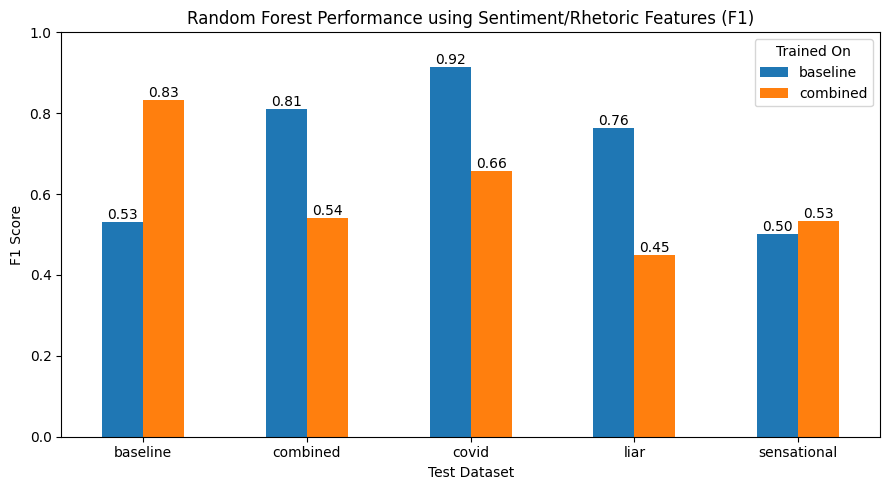

In [ ]:
# Visual: RF F1 comparison

plot_df = results_df[results_df["model"] == "SentRhet_RF"]

pivot_f1 = plot_df.pivot(
    index="test_dataset",
    columns="train_dataset",
    values="f1"
)

ax = pivot_f1.plot(kind="bar", figsize=(9, 5))
ax.set_title("Random Forest Performance using Sentiment/Rhetoric Features (F1)")
ax.set_ylabel("F1 Score")
ax.set_xlabel("Test Dataset")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Trained On")

# Add F1 scores on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()



---

Save Model

In [ ]:
# =========================
# Save trained sentiment/rhetoric models
# =========================

import joblib

MODEL_OUT_DIR = "/content/drive/MyDrive/Senior_Project/02_Models/Saved_Models"
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

# Save trained models
for model_key, model in trained_sent_rhet_models.items():
    model_path = f"{MODEL_OUT_DIR}/{model_key}.joblib"
    joblib.dump(model, model_path)
    print("Saved:", model_path)

# Save feature column order
feature_cols_path = f"{MODEL_OUT_DIR}/sent_rhet_feature_cols.joblib"
joblib.dump(feature_cols, feature_cols_path)

print("Saved feature columns:", feature_cols_path)

Saved: /content/drive/MyDrive/Senior_Project/02_Models/Saved_Models/baseline_SentRhet_LogReg.joblib
Saved: /content/drive/MyDrive/Senior_Project/02_Models/Saved_Models/baseline_SentRhet_RF.joblib
Saved: /content/drive/MyDrive/Senior_Project/02_Models/Saved_Models/combined_SentRhet_LogReg.joblib
Saved: /content/drive/MyDrive/Senior_Project/02_Models/Saved_Models/combined_SentRhet_RF.joblib
Saved feature columns: /content/drive/MyDrive/Senior_Project/02_Models/Saved_Models/sent_rhet_feature_cols.joblib
